# Evaluator-Optimizer Pattern

**Pattern**: Iterative workflow where a generator produces output, an evaluator assesses it, and loops until quality threshold is met.

**Example**: Blog Post Generator with Quality Refinement

**Workflow**:
```
START → [Generator] → [Evaluator] → (Score < Threshold?) → [Loop Back to Generator]
                                  → (Score >= Threshold?) → END
```

**Key Concept**: 
- Generator creates/improves content
- Evaluator scores and provides feedback
- Conditional edge decides: improve further or finish
- Loop continues until quality is acceptable or max iterations reached

## Setup

In [1]:
from typing import TypedDict, Literal, Annotated
import json
import operator

from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from langchain_aws import ChatBedrockConverse

## Initialize LLM

In [2]:
llm = ChatBedrockConverse(
    model="us.anthropic.claude-sonnet-4-6",
    temperature=0.7,  # Higher temperature for creative generation
)

## Define Output Models

In [3]:
class EvaluationResult(BaseModel):
    score: float  # 0.0 to 10.0
    strengths: list[str]
    weaknesses: list[str]
    suggestions: list[str]

## Define State

In [4]:
class BlogState(TypedDict):
    # Input
    topic: str
    target_audience: str
    
    # Generator output
    draft: str
    
    # Evaluator output
    score: float
    feedback: str
    strengths: list[str]
    weaknesses: list[str]
    suggestions: list[str]
    
    # Iteration tracking
    iteration: int
    max_iterations: int
    score_threshold: float
    
    # History (for tracking improvements)
    history: Annotated[list[dict], operator.add]

## Node 1: Generator

Creates initial draft or improves based on feedback.

In [5]:
def generator(state: BlogState) -> dict:
    """Generate or improve blog post draft."""
    
    iteration = state.get("iteration", 0) + 1
    
    if iteration == 1:
        # First iteration: generate initial draft
        prompt = f"""Write a blog post on the following topic.

Topic: {state['topic']}
Target Audience: {state['target_audience']}

Requirements:
- Engaging introduction that hooks the reader
- Clear structure with headings
- Informative content with examples
- Actionable conclusion
- 300-500 words

Write the blog post:"""
    else:
        # Subsequent iterations: improve based on feedback
        prompt = f"""Improve this blog post based on the feedback provided.

CURRENT DRAFT:
{state['draft']}

EVALUATION SCORE: {state['score']}/10

WEAKNESSES TO ADDRESS:
{chr(10).join('- ' + w for w in state['weaknesses'])}

SUGGESTIONS FOR IMPROVEMENT:
{chr(10).join('- ' + s for s in state['suggestions'])}

STRENGTHS TO KEEP:
{chr(10).join('- ' + s for s in state['strengths'])}

Rewrite the blog post addressing the weaknesses while keeping the strengths.
Target Audience: {state['target_audience']}

Improved blog post:"""
    
    response = llm.invoke(prompt)
    
    return {
        "draft": response.content,
        "iteration": iteration,
        "history": [{
            "iteration": iteration,
            "action": "generated" if iteration == 1 else "improved",
            "draft_preview": response.content[:200] + "..."
        }]
    }

## Node 2: Evaluator

Scores the draft and provides structured feedback.

In [6]:
def evaluator(state: BlogState) -> dict:
    """Evaluate the blog post draft."""
    
    prompt = f"""Evaluate this blog post critically.

BLOG POST:
{state['draft']}

TARGET AUDIENCE: {state['target_audience']}

Evaluate based on:
1. Clarity and readability
2. Engagement and hook
3. Structure and flow
4. Value and informativeness
5. Audience appropriateness

Return ONLY valid JSON (no markdown, no extra text):
{{
    "score": <float 0-10>,
    "strengths": ["strength1", "strength2", ...],
    "weaknesses": ["weakness1", "weakness2", ...],
    "suggestions": ["suggestion1", "suggestion2", ...]
}}

Be critical but fair. Score 7+ means good quality, 8+ means excellent."""
    
    response = llm.invoke(prompt)
    
    try:
        result = json.loads(response.content)
    except json.JSONDecodeError:
        # Fallback parsing
        import re
        json_match = re.search(r"\{.*\}", response.content, re.DOTALL)
        if json_match:
            result = json.loads(json_match.group())
        else:
            result = {
                "score": 5.0,
                "strengths": ["Unable to parse evaluation"],
                "weaknesses": ["Evaluation failed"],
                "suggestions": ["Please try again"]
            }
    
    # Build feedback summary
    feedback = f"Score: {result['score']}/10. "
    if result['weaknesses']:
        feedback += f"Main issues: {', '.join(result['weaknesses'][:2])}."
    
    return {
        "score": result["score"],
        "strengths": result["strengths"],
        "weaknesses": result["weaknesses"],
        "suggestions": result["suggestions"],
        "feedback": feedback,
        "history": [{
            "iteration": state["iteration"],
            "action": "evaluated",
            "score": result["score"]
        }]
    }

## Routing Function: Continue or Finish?

Decides whether to loop back to generator or finish.

In [7]:
def should_continue(state: BlogState) -> Literal["generator", "end"]:
    """
    Decide whether to continue improving or finish.
    
    Finish if:
    - Score meets threshold, OR
    - Max iterations reached
    """
    score = state.get("score", 0)
    iteration = state.get("iteration", 0)
    max_iterations = state.get("max_iterations", 3)
    threshold = state.get("score_threshold", 7.5)
    
    # Check termination conditions
    if score >= threshold:
        print(f"   [DECISION] Score {score} >= threshold {threshold}. Finishing.")
        return "end"
    
    if iteration >= max_iterations:
        print(f"   [DECISION] Max iterations ({max_iterations}) reached. Finishing.")
        return "end"
    
    print(f"   [DECISION] Score {score} < threshold {threshold}. Improving...")
    return "generator"

## Build the Graph

In [8]:
# Create graph
builder = StateGraph(BlogState)

# Add nodes
builder.add_node("generator", generator)
builder.add_node("evaluator", evaluator)

# Add edges
builder.add_edge(START, "generator")
builder.add_edge("generator", "evaluator")

# Conditional edge: loop back or finish
builder.add_conditional_edges(
    "evaluator",
    should_continue,
    {
        "generator": "generator",  # Loop back
        "end": END                   # Finish
    }
)

# Compile
graph = builder.compile()

## Visualize the Graph

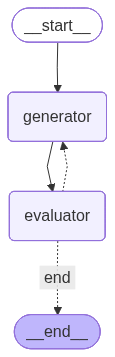

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Helper: Display Results

In [10]:
def display_results(result: dict) -> None:
    """Pretty print the final result."""
    print("=" * 70)
    print("              EVALUATOR-OPTIMIZER RESULTS")
    print("=" * 70)
    
    print(f"\nTopic: {result['topic']}")
    print(f"Target Audience: {result['target_audience']}")
    print(f"Total Iterations: {result['iteration']}")
    print(f"Final Score: {result['score']}/10")
    
    print("\n" + "-" * 70)
    print("ITERATION HISTORY")
    print("-" * 70)
    for entry in result['history']:
        if entry['action'] == 'evaluated':
            print(f"  Iteration {entry['iteration']}: Score = {entry['score']}")
    
    print("\n" + "-" * 70)
    print("FINAL EVALUATION")
    print("-" * 70)
    print(f"\n[STRENGTHS]")
    for s in result['strengths']:
        print(f"  + {s}")
    
    print(f"\n[WEAKNESSES]")
    for w in result['weaknesses']:
        print(f"  - {w}")
    
    print("\n" + "-" * 70)
    print("FINAL BLOG POST")
    print("-" * 70)
    print(f"\n{result['draft']}")
    
    print("\n" + "=" * 70)

## Test Case 1: Standard Run (3 Max Iterations)

In [11]:
result = graph.invoke({
    "topic": "Introduction to LangGraph for Beginners",
    "target_audience": "Python developers new to AI agents",
    "iteration": 0,
    "max_iterations": 3,
    "score_threshold": 7.5,
    "history": []
})

display_results(result)

   [DECISION] Score 7.2 < threshold 7.5. Improving...
   [DECISION] Score 8.2 >= threshold 7.5. Finishing.
              EVALUATOR-OPTIMIZER RESULTS

Topic: Introduction to LangGraph for Beginners
Target Audience: Python developers new to AI agents
Total Iterations: 2
Final Score: 8.2/10

----------------------------------------------------------------------
ITERATION HISTORY
----------------------------------------------------------------------
  Iteration 1: Score = 7.2
  Iteration 2: Score = 8.2

----------------------------------------------------------------------
FINAL EVALUATION
----------------------------------------------------------------------

[STRENGTHS]
  + The opening hook directly addresses the reader's emotional state with relatable framing, immediately establishing relevance for the target audience
  + The visual ASCII flowchart is an excellent pedagogical device that makes the abstract graph concept concrete before any code is introduced
  + The three-concept summar

## Test Case 2: High Quality Threshold

In [12]:
result = graph.invoke({
    "topic": "5 Tips for Writing Clean Python Code",
    "target_audience": "Junior developers",
    "iteration": 0,
    "max_iterations": 5,
    "score_threshold": 8.5,  # Higher threshold
    "history": []
})

display_results(result)

   [DECISION] Score 7.8 < threshold 8.5. Improving...
   [DECISION] Score 8.6 >= threshold 8.5. Finishing.
              EVALUATOR-OPTIMIZER RESULTS

Topic: 5 Tips for Writing Clean Python Code
Target Audience: Junior developers
Total Iterations: 2
Final Score: 8.6/10

----------------------------------------------------------------------
ITERATION HISTORY
----------------------------------------------------------------------
  Iteration 1: Score = 7.8
  Iteration 2: Score = 8.6

----------------------------------------------------------------------
FINAL EVALUATION
----------------------------------------------------------------------

[STRENGTHS]
  + Conversational tone with relatable opening anecdote (Friday afternoon script) immediately establishes rapport with junior developers without being condescending
  + Code examples are well-chosen and genuinely illustrative — the magic numbers example is particularly strong because it uses the same value (30) for two different purposes, ma

## Test Case 3: Single Iteration (High Initial Quality Expected)

In [13]:
result = graph.invoke({
    "topic": "What is Machine Learning?",
    "target_audience": "Non-technical business executives",
    "iteration": 0,
    "max_iterations": 1,  # Only 1 iteration allowed
    "score_threshold": 9.0,
    "history": []
})

display_results(result)

   [DECISION] Max iterations (1) reached. Finishing.
              EVALUATOR-OPTIMIZER RESULTS

Topic: What is Machine Learning?
Target Audience: Non-technical business executives
Total Iterations: 1
Final Score: 7.4/10

----------------------------------------------------------------------
ITERATION HISTORY
----------------------------------------------------------------------
  Iteration 1: Score = 7.4

----------------------------------------------------------------------
FINAL EVALUATION
----------------------------------------------------------------------

[STRENGTHS]
  + The opening coffee shop analogy is immediately relatable and effectively bridges an abstract concept to a familiar human experience
  + Consistent use of bold text and bullet points creates strong visual hierarchy that suits executive readers who skim content
  + The Netflix example is well-chosen — nearly universally recognized by the target audience and concretely illustrates the core concept
  + The McKinsey 

## Stream Execution (Watch the Loop)

In [14]:
print("=" * 70)
print("STREAMING EXECUTION - Watch the Evaluator-Optimizer Loop")
print("=" * 70)

for step in graph.stream({
    "topic": "Benefits of Test-Driven Development",
    "target_audience": "Software engineering teams",
    "iteration": 0,
    "max_iterations": 3,
    "score_threshold": 7.5,
    "history": []
}):
    for node_name, output in step.items():
        if node_name == "generator":
            print(f"\n[GENERATOR] Iteration {output.get('iteration', '?')}")
            print(f"   Draft preview: {output['draft'][:100]}...")
        elif node_name == "evaluator":
            print(f"\n[EVALUATOR] Score: {output['score']}/10")
            print(f"   Feedback: {output['feedback']}")

STREAMING EXECUTION - Watch the Evaluator-Optimizer Loop

[GENERATOR] Iteration 1
   Draft preview: # Why Writing Tests First Will Transform Your Team's Code

Imagine shipping a major feature on Frida...
   [DECISION] Score 7.4 < threshold 7.5. Improving...

[EVALUATOR] Score: 7.4/10
   Feedback: Score: 7.4/10. Main issues: The 40-80% defect reduction statistic is presented without a direct citation, link, or study name — 'Microsoft and IBM' is vague and a technical audience will likely scrutinize this, The 'Common Pushbacks' section is dismissive and shallow, labeling objections as simply 'wrong' without substantive engagement — engineers will find this intellectually dishonest.

[GENERATOR] Iteration 2
   Draft preview: # Why Writing Tests First Will Transform Your Team's Code

Imagine shipping a major feature on Frida...
   [DECISION] Score 8.6 >= threshold 7.5. Finishing.

[EVALUATOR] Score: 8.6/10
   Feedback: Score: 8.6/10. Main issues: The refactored code example in Step 3 is sl

## Key Takeaways

1. **Evaluator-Optimizer** is an iterative refinement pattern using loops
2. **Generator** produces content, **Evaluator** assesses quality
3. **Conditional edge** creates the loop: routes back to generator or exits
4. **Termination conditions** prevent infinite loops:
   - Score meets threshold
   - Max iterations reached
5. **Feedback flows** from evaluator to generator for targeted improvements

### Loop Pattern:
```python
def should_continue(state):
    if state["score"] >= threshold or state["iteration"] >= max_iter:
        return "end"
    return "generator"  # Loop back

graph.add_conditional_edges(
    "evaluator",
    should_continue,
    {"generator": "generator", "end": END}
)
```

### Use Cases:
- Content generation with quality control
- Code generation with test validation
- Translation with accuracy checks
- Any task requiring iterative refinement